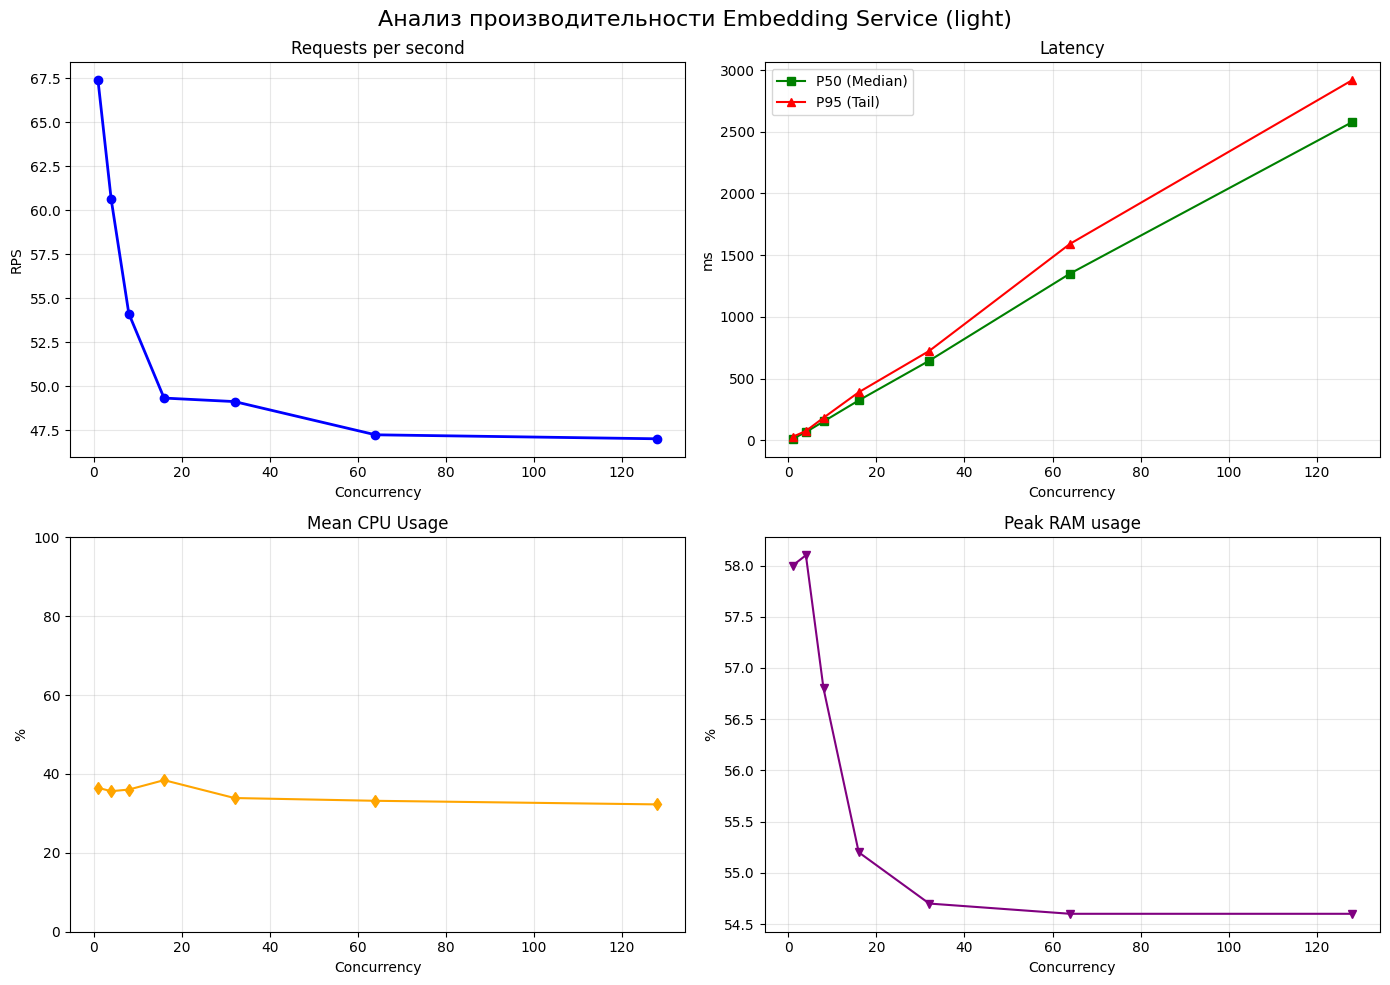

In [1]:
import matplotlib.pyplot as plt
import glob
import json


files = sorted(glob.glob("benchmark_data/light_benchmark_report_*"))
if not files:
    print("Файлы отчетов не найдены.")

data_list = []
for f in files:
    with open(f, "r") as j:
        data_list.append(json.load(j))

data_list.sort(key=lambda x: x["concurrency"])

c = [d["concurrency"] for d in data_list]
rps = [d["stats"]["rps"] for d in data_list]
p50 = [d["stats"]["p50_ms"] for d in data_list]
p95 = [d["stats"]["p95_ms"] for d in data_list]
cpu = [d["resources"]["avg_cpu_percent"] for d in data_list]
mem = [d["resources"]["max_mem_percent"] for d in data_list]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Анализ производительности Embedding Service (light)", fontsize=16)

axs[0, 0].plot(c, rps, "o-", color="blue", linewidth=2)
axs[0, 0].set_title("Requests per second")
axs[0, 0].set_ylabel("RPS")
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].plot(c, p50, "s-", label="P50 (Median)", color="green")
axs[0, 1].plot(c, p95, "^-", label="P95 (Tail)", color="red")
axs[0, 1].set_title("Latency")
axs[0, 1].set_ylabel("ms")
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].plot(c, cpu, "d-", color="orange")
axs[1, 0].set_title("Mean CPU Usage")
axs[1, 0].set_ylabel("%")
axs[1, 0].set_ylim(0, 100)
axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].plot(c, mem, "v-", color="purple")
axs[1, 1].set_title("Peak RAM usage")
axs[1, 1].set_ylabel("%")
axs[1, 1].grid(True, alpha=0.3)

for ax in axs.flat:
    ax.set_xlabel("Concurrency")

plt.tight_layout()
plt.savefig("light_benchmark_analysis_plot.png")
plt.show()

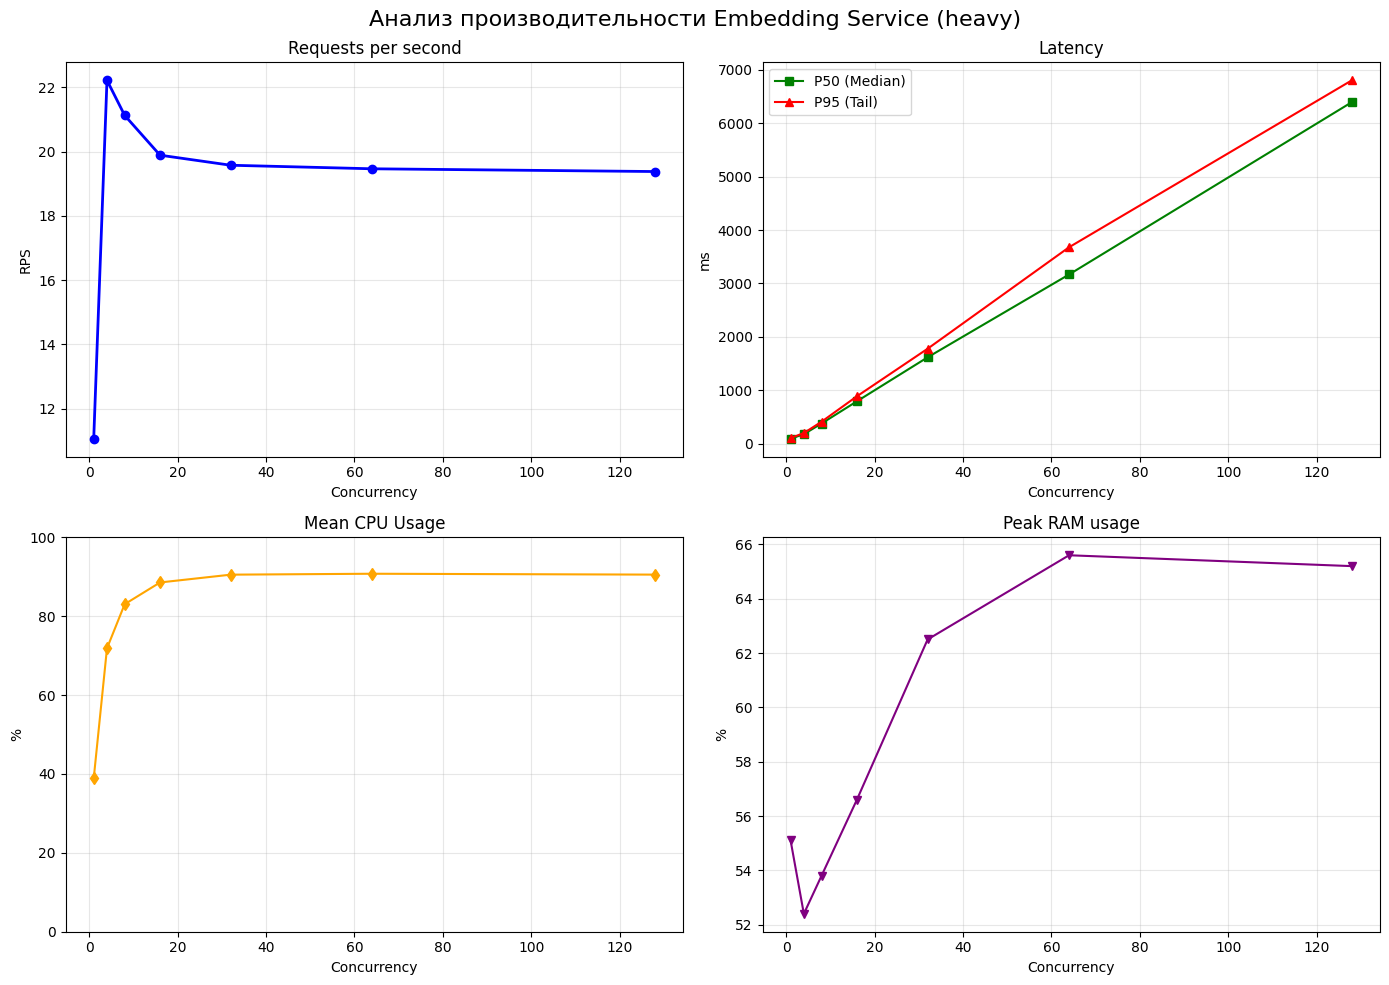

In [2]:
files = sorted(glob.glob("benchmark_data/heavy_benchmark_report_*"))
if not files:
    print("Файлы отчетов не найдены.")

data_list = []
for f in files:
    with open(f, "r") as j:
        data_list.append(json.load(j))

data_list.sort(key=lambda x: x["concurrency"])

c = [d["concurrency"] for d in data_list]
rps = [d["stats"]["rps"] for d in data_list]
p50 = [d["stats"]["p50_ms"] for d in data_list]
p95 = [d["stats"]["p95_ms"] for d in data_list]
cpu = [d["resources"]["avg_cpu_percent"] for d in data_list]
mem = [d["resources"]["max_mem_percent"] for d in data_list]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Анализ производительности Embedding Service (heavy)", fontsize=16)

axs[0, 0].plot(c, rps, "o-", color="blue", linewidth=2)
axs[0, 0].set_title("Requests per second")
axs[0, 0].set_ylabel("RPS")
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].plot(c, p50, "s-", label="P50 (Median)", color="green")
axs[0, 1].plot(c, p95, "^-", label="P95 (Tail)", color="red")
axs[0, 1].set_title("Latency")
axs[0, 1].set_ylabel("ms")
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].plot(c, cpu, "d-", color="orange")
axs[1, 0].set_title("Mean CPU Usage")
axs[1, 0].set_ylabel("%")
axs[1, 0].set_ylim(0, 100)
axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].plot(c, mem, "v-", color="purple")
axs[1, 1].set_title("Peak RAM usage")
axs[1, 1].set_ylabel("%")
axs[1, 1].grid(True, alpha=0.3)

for ax in axs.flat:
    ax.set_xlabel("Concurrency")

plt.tight_layout()
plt.savefig("heavy_benchmark_analysis_plot.png")
plt.show()